In [1]:
from framework import FrameWork
from framework import AveragedPerdiction
from framework import BorexinoRecoilSpectrum

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex']=True
plt.style.use('classic')


In [2]:
frame           = FrameWork(m12_nuisance=False)
dr_dldt         = frame[[33.4,0]]

In [3]:
pred_bo,pred_su = AveragedPerdiction(dr_dldt,frame)

In [5]:
print(frame.borom_unoscilated)

[18000690.16843867 16766211.16376327 15457464.04734349 14096790.95469774
 12708414.93676814 11317208.54744045  9947614.93802176  8622730.67605823
  7363517.61875995  6188118.52578503  5111277.27882673  4143880.99155685
  3292651.2772633   2560020.26697886  1944226.10559886  1439647.43843033
  1037372.40528589   725971.8169456    492419.35589871   323074.21290731
   329487.4525952    114523.69338097    44070.03506342]


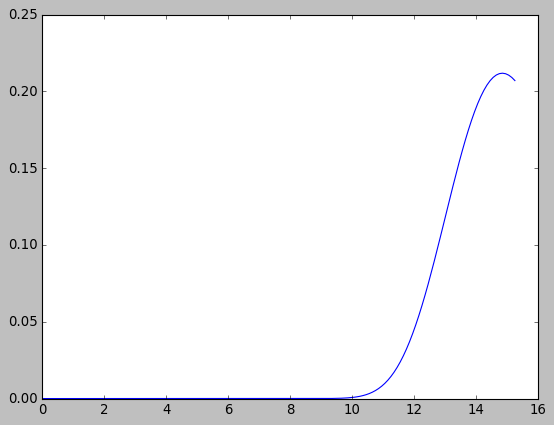

In [18]:
plt.plot(frame.t_e['B8'][0],frame.res[-2])

In [ ]:
# pred_bo,pred_su = AveragedPerdiction(dr_dldt,frame.t_e,frame.year,frame.theta,frame.det_su,
#                                      frame.borom_unoscilated,frame.res,frame.components)



#elrec_B8   = BorexinoRecoilSpectrum(dr_dldt[0]['B8'][0],frame.t_e['B8'][0],frame.year,frame.theta)

In [4]:
print(pred_bo)
print()
print(pred_su)

[[137.71769627  48.31094759   2.761345  ]]

[[0.47660856 0.47141657 0.46658985 0.46213539 0.45804984 0.45432176
  0.45093392 0.44786539 0.44509334 0.4425943  0.44034515 0.43832372
  0.43650911 0.43488186 0.43342398 0.43211883 0.43095106 0.42990652
  0.42897225 0.42813649 0.42713498 0.42592612 0.42474173]]


In [7]:
print(np.trapz((elrec_be70+elrec_be71)[60:339]))

21.616758440866075


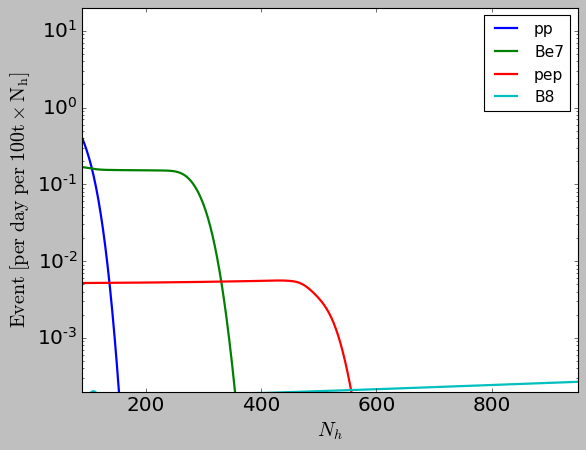

In [3]:
plt.rcParams.update({'font.size': 18})
plt.ylim(2e-4,20)
plt.yscale('log')
plt.xlim(90,950)
plt.plot(np.arange(90,950,1),elrec_pp,'b-',lw=2,label='pp')
plt.plot(np.arange(90,950,1),elrec_be70+elrec_be71,'g-',lw=2,label='Be7')
plt.plot(np.arange(90,950,1),elrec_pep,'r-',lw=2,label='pep')
plt.plot(np.arange(90,950,1),elrec_B8,'c-',lw=2,label='B8')
plt.xlabel(r'$N_h$')
plt.ylabel(r'$\rm Event \ [per \ day \ per \ 100t \times N_h]$')

plt.legend(fontsize=14)

In [7]:
def DataIndex():
    one_binning    = np.arange(1,366)
    thirty_binning = [[]for i in range(119)]
    for i in range(341,3570+341):   #341 and 3570+341 are corresponding to 11 dec 2011 to 3 Oct 2021
        thirty_binning[(i-341)//30].append(one_binning[np.mod(i,365)])

    data_index = np.zeros((31,116))
    k = 0
    for i in range(116):
        if i==54:
            k=k+2
        if i==90:
            k=k+1

        data_index[0,i]  = 15 + 30 * k
        data_index[1:,i] = thirty_binning[k]
        k = k + 1
    return data_index


data_index  = DataIndex()


print(data_index)

[[  15.   45.   75. ... 3495. 3525. 3555.]
 [ 342.    7.   37. ...  172.  202.  232.]
 [ 343.    8.   38. ...  173.  203.  233.]
 ...
 [   4.   34.   64. ...  199.  229.  259.]
 [   5.   35.   65. ...  200.  230.  260.]
 [   6.   36.   66. ...  201.  231.  261.]]
